In [73]:
from sklearn.datasets import make_moons
import torch
import matplotlib.pyplot as plt
from torch import nn, optim
from sklearn.model_selection import train_test_split
from torch.utils.data  import DataLoader, TensorDataset

In [74]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

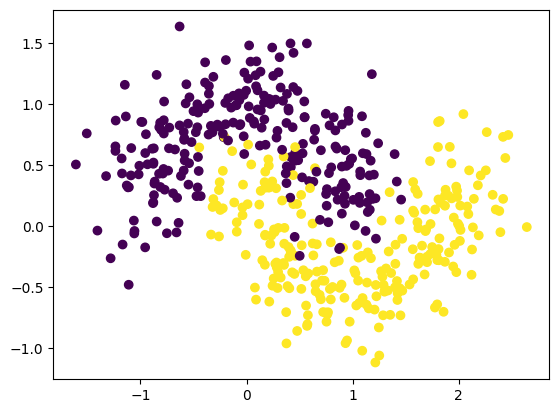

In [75]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [76]:
# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42,
                                                  shuffle=True, train_size=0.8)

In [77]:
# Convert into tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

In [78]:
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

In [79]:
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_baseline = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_baseline.append(loss_val.item())

Epoch 0
Training set loss: 0.5991
Validation set loss: 0.4675
Epoch 20
Training set loss: 0.1069
Validation set loss: 0.1729
Epoch 40
Training set loss: 0.0854
Validation set loss: 0.1317
Epoch 60
Training set loss: 0.0919
Validation set loss: 0.1075
Epoch 80
Training set loss: 0.0944
Validation set loss: 0.1588
Epoch 100
Training set loss: 0.0848
Validation set loss: 0.1702
Epoch 120
Training set loss: 0.0764
Validation set loss: 0.1611
Epoch 140
Training set loss: 0.0775
Validation set loss: 0.1983
Epoch 160
Training set loss: 0.0719
Validation set loss: 0.1786
Epoch 180
Training set loss: 0.0770
Validation set loss: 0.1465
Epoch 199
Training set loss: 0.0725
Validation set loss: 0.1585


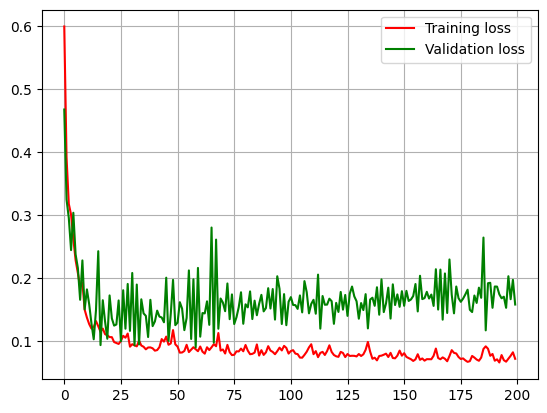

In [80]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_baseline, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

In [81]:
# Now train with Dropout (deactivating some neurons)
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_dropout = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_dropout.append(loss_val.item())

Epoch 0
Training set loss: 0.6356
Validation set loss: 0.5014
Epoch 20
Training set loss: 0.1559
Validation set loss: 0.1630
Epoch 40
Training set loss: 0.1526
Validation set loss: 0.1589
Epoch 60
Training set loss: 0.1203
Validation set loss: 0.1687
Epoch 80
Training set loss: 0.0956
Validation set loss: 0.1918
Epoch 100
Training set loss: 0.1039
Validation set loss: 0.1727
Epoch 120
Training set loss: 0.1220
Validation set loss: 0.1519
Epoch 140
Training set loss: 0.1063
Validation set loss: 0.1744
Epoch 160
Training set loss: 0.0945
Validation set loss: 0.1639
Epoch 180
Training set loss: 0.0942
Validation set loss: 0.1775
Epoch 199
Training set loss: 0.0876
Validation set loss: 0.1621


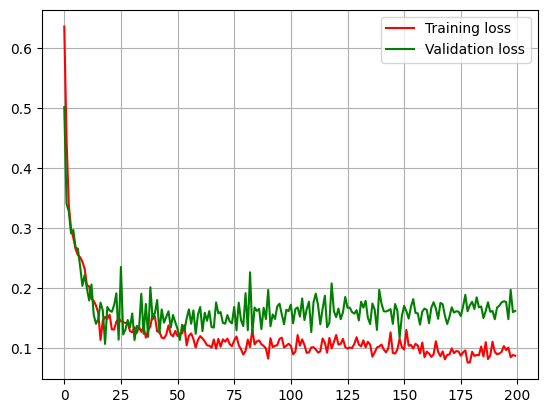

In [82]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_dropout, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

In [83]:
# Now train with only Batch Norm.
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_batch = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_batch.append(loss_val.item())

Epoch 0
Training set loss: 0.3414
Validation set loss: 0.4827
Epoch 20
Training set loss: 0.1451
Validation set loss: 0.1740
Epoch 40
Training set loss: 0.1917
Validation set loss: 0.1636
Epoch 60
Training set loss: 0.1355
Validation set loss: 0.1711
Epoch 80
Training set loss: 0.1565
Validation set loss: 0.2044
Epoch 100
Training set loss: 0.1421
Validation set loss: 0.1569
Epoch 120
Training set loss: 0.1738
Validation set loss: 0.1628
Epoch 140
Training set loss: 0.1905
Validation set loss: 0.1907
Epoch 160
Training set loss: 0.2007
Validation set loss: 0.2007
Epoch 180
Training set loss: 0.1438
Validation set loss: 0.1520
Epoch 199
Training set loss: 0.1480
Validation set loss: 0.1598


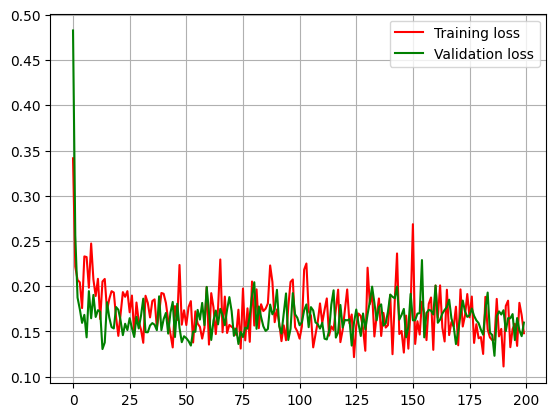

In [84]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_batch, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.show()

In [85]:
# Now train with both Dropout and Batch Norm.
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

losses_train = []
losses_val_both = []

loss_ft = nn.BCELoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):

  total_train_loss = 0
  model.train()

  for X_batch, y_batch in train_loader:
    pred_train = model(X_batch)
    loss_train = loss_ft(pred_train, y_batch)
    loss_train.backward()
    opt.step()
    opt.zero_grad()
    total_train_loss += loss_train.item()

  avg_train_loss = total_train_loss / len(train_loader)

  model.eval()
  with torch.no_grad():
    pred_val = model(X_val_t)
    loss_val = loss_ft(pred_val, y_val_t)

  if epoch % 20 == 0 or epoch == 199:
    print(f'Epoch {epoch}')
    print(f'Training set loss: {avg_train_loss:.4f}')
    print(f'Validation set loss: {loss_val:.4f}')

  losses_train.append(avg_train_loss)
  losses_val_both.append(loss_val.item())

Epoch 0
Training set loss: 0.4558
Validation set loss: 0.4242
Epoch 20
Training set loss: 0.2221
Validation set loss: 0.1553
Epoch 40
Training set loss: 0.2000
Validation set loss: 0.1566
Epoch 60
Training set loss: 0.2014
Validation set loss: 0.1610
Epoch 80
Training set loss: 0.2305
Validation set loss: 0.1694
Epoch 100
Training set loss: 0.1649
Validation set loss: 0.1874
Epoch 120
Training set loss: 0.2807
Validation set loss: 0.1464
Epoch 140
Training set loss: 0.1957
Validation set loss: 0.1716
Epoch 160
Training set loss: 0.1491
Validation set loss: 0.1573
Epoch 180
Training set loss: 0.1838
Validation set loss: 0.1417
Epoch 199
Training set loss: 0.1608
Validation set loss: 0.1456


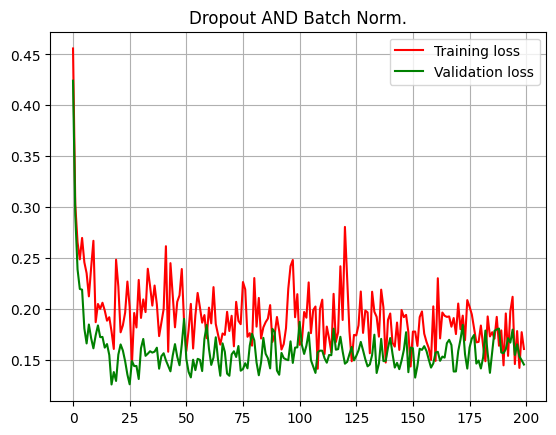

In [86]:
plt.plot(losses_train, color='red', label='Training loss')
plt.plot(losses_val_both, color='green', label='Validation loss')
plt.legend()
plt.grid()
plt.title('Dropout AND Batch Norm.')
plt.show()

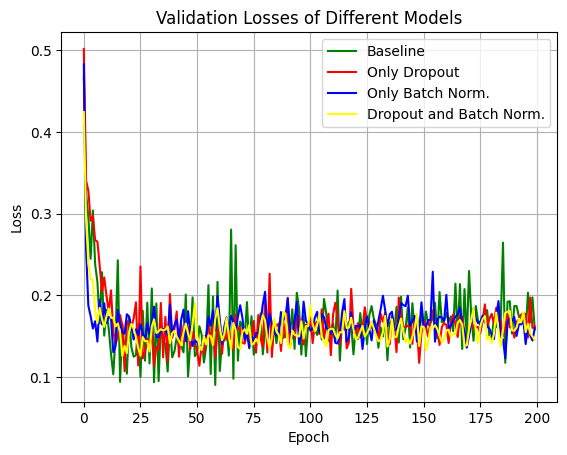

In [90]:
plt.plot(losses_val_baseline, color='green', label='Baseline')
plt.plot(losses_val_dropout, color='red', label='Only Dropout')
plt.plot(losses_val_batch, color='blue', label='Only Batch Norm.')
plt.plot(losses_val_both, color='yellow', label='Dropout and Batch Norm.')
plt.title('Validation Losses of Different Models')
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()